# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama**       : Hayqal Akbar Rizky Iskandar
- **Email**      : cdcc179d6y0826@student.devacademy.id
- **ID Dicoding**: Hayqal Akbar Rizky Iskandar

1. Bagaimana tren jumlah pesanan bulanan pada platform e-commerce Brasil dari Januari 2017 hingga Agustus 2018, dan pada bulan apa terjadi lonjakan pesanan tertinggi?
2. Kategori produk apa yang memiliki jumlah penjualan terbanyak dan menghasilkan revenue tertinggi selama periode 2016–2018, serta seberapa besar kontribusinya terhadap total pendapatan?
3. Bagaimana distribusi geografis pelanggan berdasarkan state di Brasil selama periode 2016–2018, dan state mana yang mendominasi jumlah pelanggan aktif?
4. Bagaimana karakteristik pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary) selama periode 2016–2018, dan siapa saja pelanggan dengan nilai transaksi dan frekuensi pembelian tertinggi?

## Import Semua Packages/Library yang Digunakan

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [7]:
DATA_PATH = r"C:\Users\LEGION\submission\data\E-Commerce Public Dataset\\"

customers_df      = pd.read_csv(DATA_PATH + 'customers_dataset.csv')
geolocation_df    = pd.read_csv(DATA_PATH + 'geolocation_dataset.csv')
order_items_df    = pd.read_csv(DATA_PATH + 'order_items_dataset.csv')
order_payments_df = pd.read_csv(DATA_PATH + 'order_payments_dataset.csv')
order_reviews_df  = pd.read_csv(DATA_PATH + 'order_reviews_dataset.csv')
orders_df         = pd.read_csv(DATA_PATH + 'orders_dataset.csv')
products_df       = pd.read_csv(DATA_PATH + 'products_dataset.csv')
sellers_df        = pd.read_csv(DATA_PATH + 'sellers_dataset.csv')
category_df       = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

## Data Wrangling

### Gathering Data

In [8]:
print('=== customers_df ===')
display(customers_df.head(3))

print('=== orders_df ===')
display(orders_df.head(3))

print('=== order_items_df ===')
display(order_items_df.head(3))

print('=== products_df ===')
display(products_df.head(3))

print('=== geolocation_df ===')
display(geolocation_df.head(3))

=== customers_df ===


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


=== orders_df ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


=== order_items_df ===


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


=== products_df ===


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


=== geolocation_df ===


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP


> **Insight:** Dataset E-Commerce terdiri dari 9 tabel yang saling terhubung melalui foreign key seperti `order_id`, `customer_id`, `product_id`, dan `seller_id`. Dataset mencakup informasi transaksi, produk, pelanggan, penjual, dan geolokasi di Brasil.

### Assessing Data

In [9]:
datasets = {
    'customers_df'      : customers_df,
    'geolocation_df'    : geolocation_df,
    'order_items_df'    : order_items_df,
    'order_payments_df' : order_payments_df,
    'order_reviews_df'  : order_reviews_df,
    'orders_df'         : orders_df,
    'products_df'       : products_df,
    'sellers_df'        : sellers_df,
    'category_df'       : category_df
}

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    duplicates = df.duplicated().sum()
    print(f'\n=== {name} ===')
    print(f'Shape        : {df.shape}')
    print(f'Duplicates   : {duplicates}')
    if len(missing) > 0:
        print('Missing Values:')
        print(missing)
    else:
        print('Missing Values: None')


=== customers_df ===
Shape        : (99441, 5)
Duplicates   : 0
Missing Values: None

=== geolocation_df ===
Shape        : (1000163, 5)
Duplicates   : 261831
Missing Values: None

=== order_items_df ===
Shape        : (112650, 7)
Duplicates   : 0
Missing Values: None

=== order_payments_df ===
Shape        : (103886, 5)
Duplicates   : 0
Missing Values: None

=== order_reviews_df ===
Shape        : (99224, 7)
Duplicates   : 0
Missing Values:
review_comment_title      87656
review_comment_message    58247
dtype: int64

=== orders_df ===
Shape        : (99441, 8)
Duplicates   : 0
Missing Values:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

=== products_df ===
Shape        : (32951, 9)
Duplicates   : 0
Missing Values:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm    

In [10]:
print(orders_df.dtypes)
print()
print(orders_df.describe())

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

                                order_id                       customer_id  \
count                              99441                             99441   
unique                             99441                             99441   
top     e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
freq                                   1                                 1   

       order_status order_purchase_timestamp    order_approved_at  \
count         99441                    99441                99281   
unique            8                    98875                90733   
top       delivered      2018-08-02 12:05:26  2018-02-27 04:31:10  

> **Insight:** Terdapat missing values pada beberapa kolom di `orders_df` (kolom timestamp pengiriman) dan `products_df` (nama kategori). Kolom bertipe datetime masih berformat string sehingga perlu dikonversi. Terdapat duplikat pada `geolocation_df` yang perlu dihapus.

### Cleaning Data

In [11]:
# 1. Konversi kolom datetime pada orders_df
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

print('Tipe data setelah konversi:')
print(orders_df[datetime_cols].dtypes)

Tipe data setelah konversi:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [12]:
# 2. Hapus duplikat pada geolocation_df
print(f'Sebelum drop duplikat: {geolocation_df.shape}')
geolocation_df = geolocation_df.drop_duplicates()
print(f'Setelah drop duplikat : {geolocation_df.shape}')

Sebelum drop duplikat: (1000163, 5)
Setelah drop duplikat : (738332, 5)


In [13]:
# 3. Handle missing values pada products_df
print(f'Missing sebelum: {products_df["product_category_name"].isnull().sum()}')
products_df['product_category_name'] = products_df['product_category_name'].fillna('unknown')
print(f'Missing setelah : {products_df["product_category_name"].isnull().sum()}')

Missing sebelum: 610
Missing setelah : 0


In [14]:
# 4. Filter orders yang berstatus 'delivered'
print(f'Status order unik: {orders_df["order_status"].unique()}')
orders_delivered = orders_df[orders_df['order_status'] == 'delivered'].copy()
print(f'Jumlah order delivered: {orders_delivered.shape[0]}')

Status order unik: ['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'
 'created' 'approved']
Jumlah order delivered: 96478


In [15]:
# 5. Gabungkan products_df dengan terjemahan kategori
products_df = products_df.merge(category_df, on='product_category_name', how='left')
products_df['product_category_name_english'] = products_df['product_category_name_english'].fillna('unknown')
print('Produk dengan kategori Bahasa Inggris:')
display(products_df[['product_id', 'product_category_name', 'product_category_name_english']].head())

Produk dengan kategori Bahasa Inggris:


,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares


> **Insight:** Kolom datetime berhasil dikonversi, duplikat geolocation dihapus, missing values diisi 'unknown', dan hanya order berstatus 'delivered' yang digunakan agar analisis lebih akurat.

## Export Clean Dataset for Dashboard

In [16]:
import os
os.makedirs('dashboard', exist_ok=True)

main_data = orders_delivered.merge(customers_df, on='customer_id', how='left')

main_data = main_data.merge(
    order_items_df[['order_id', 'product_id', 'price']],
    on='order_id', how='left'
)

main_data = main_data.merge(
    products_df[['product_id', 'product_category_name_english']],
    on='product_id', how='left'
)

main_data = main_data.merge(
    order_payments_df.groupby('order_id')['payment_value'].sum().reset_index(),
    on='order_id', how='left'
)

main_data.to_csv('dashboard/main_data.csv', index=False)
print('main_data.csv berhasil dibuat')
print(main_data.shape)
display(main_data.head())

main_data.csv berhasil dibuat
(110197, 16)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,price,product_category_name_english,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,87285b34884572647811a353c7ac498a,29.99,housewares,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,595fac2a385ac33a80bd5114aec74eb8,118.70,perfumery,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,aa4383b373c6aca5d8797843e5594415,159.90,auto,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,pet_shop,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,65266b2da20d04dbe00c5c2d3bb7859e,19.90,stationery,28.62


## Exploratory Data Analysis (EDA)

### EDA 1 — Tren Pesanan Bulanan

In [17]:
orders_delivered['year_month'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders_delivered.groupby('year_month').agg(
    total_orders=('order_id', 'count')
).reset_index()

monthly_orders['year_month_str'] = monthly_orders['year_month'].astype(str)

print('Top 10 bulan dengan pesanan terbanyak:')
display(monthly_orders.sort_values('total_orders', ascending=False).head(10))

Top 10 bulan dengan pesanan terbanyak:


,year_month,total_orders,year_month_str
13,2017-11,7289,2017-11
15,2018-01,7069,2018-01
17,2018-03,7003,2018-03
18,2018-04,6798,2018-04
19,2018-05,6749,2018-05
16,2018-02,6555,2018-02
22,2018-08,6351,2018-08
21,2018-07,6159,2018-07
20,2018-06,6099,2018-06
14,2017-12,5513,2017-12


> **Insight:** Terjadi peningkatan jumlah pesanan yang signifikan dari 2016 ke 2018. Bulan November 2017 menunjukkan lonjakan terbesar yang kemungkinan berkaitan dengan event Black Friday.

### EDA 2 — Kategori Produk Terlaris

In [18]:
items_products = order_items_df.merge(
    products_df[['product_id', 'product_category_name_english']],
    on='product_id', how='left'
)
items_products = items_products.merge(
    orders_delivered[['order_id']], on='order_id', how='inner'
)

category_sales = items_products.groupby('product_category_name_english').agg(
    total_sold=('order_id', 'count'),
    total_revenue=('price', 'sum')
).reset_index().sort_values('total_sold', ascending=False)

print('Top 10 Kategori Produk Terlaris:')
display(category_sales.head(10))

Top 10 Kategori Produk Terlaris:


,product_category_name_english,total_sold,total_revenue
7,bed_bath_table,10953,1023434.76
43,health_beauty,9465,1233131.72
65,sports_leisure,8431,954852.55
39,furniture_decor,8160,711927.69
15,computers_accessories,7644,888724.61
49,housewares,6795,615628.69
71,watches_gifts,5859,1166176.98
68,telephony,4430,309860.23
42,garden_tools,4268,470495.28
5,auto,4140,578966.65


> **Insight:** Kategori `bed_bath_table`, `health_beauty`, dan `sports_leisure` mendominasi penjualan. Kategori dengan penjualan tertinggi belum tentu menghasilkan revenue tertinggi karena perbedaan harga produk.

### EDA 3 — Distribusi Geografis Pelanggan

In [19]:
customer_state = customers_df.groupby('customer_state').agg(
    total_customers=('customer_id', 'count')
).reset_index().sort_values('total_customers', ascending=False)

print('Distribusi Pelanggan per State (Top 10):')
display(customer_state.head(10))

Distribusi Pelanggan per State (Top 10):


,customer_state,total_customers
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


> **Insight:** Pelanggan paling banyak berasal dari state SP (Sao Paulo), diikuti RJ dan MG. Konsentrasi di wilayah tenggara mencerminkan pusat ekonomi Brasil.

### EDA 4 — RFM Analysis

In [20]:
orders_customers = orders_delivered.merge(customers_df, on='customer_id', how='left')
orders_payments  = orders_customers.merge(
    order_payments_df.groupby('order_id')['payment_value'].sum().reset_index(),
    on='order_id', how='left'
)

reference_date = orders_payments['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = orders_payments.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    Frequency=('order_id', 'count'),
    Monetary=('payment_value', 'sum')
).reset_index()

print('RFM DataFrame:')
display(rfm_df.describe())

RFM DataFrame:


,Recency,Frequency,Monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,165.197003
std,152.591453,0.209097,226.314012
min,1.000000,1.000000,0.000000
25%,114.000000,1.000000,63.052500
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.557500
max,714.000000,15.000000,13664.080000


In [21]:
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], q=5, labels=[5,4,3,2,1])
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], q=5, labels=[1,2,3,4,5])

rfm_df['RFM_Score'] = (
    rfm_df['R_Score'].astype(int) +
    rfm_df['F_Score'].astype(int) +
    rfm_df['M_Score'].astype(int)
)

def segment_customer(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm_df['Segment'] = rfm_df['RFM_Score'].apply(segment_customer)

print('Distribusi Segmen Pelanggan:')
print(rfm_df['Segment'].value_counts())

Distribusi Segmen Pelanggan:
Segment
Potential Loyalists    38395
Loyal Customers        31506
At Risk                14629
Champions               8029
Lost                     799
Name: count, dtype: int64


> **Insight:** Sebagian besar pelanggan termasuk dalam segmen 'At Risk' dan 'Potential Loyalists'. Pelanggan 'Champions' memiliki frekuensi pembelian tinggi dan pengeluaran terbesar.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren Jumlah Pesanan Bulanan (2016–2018)

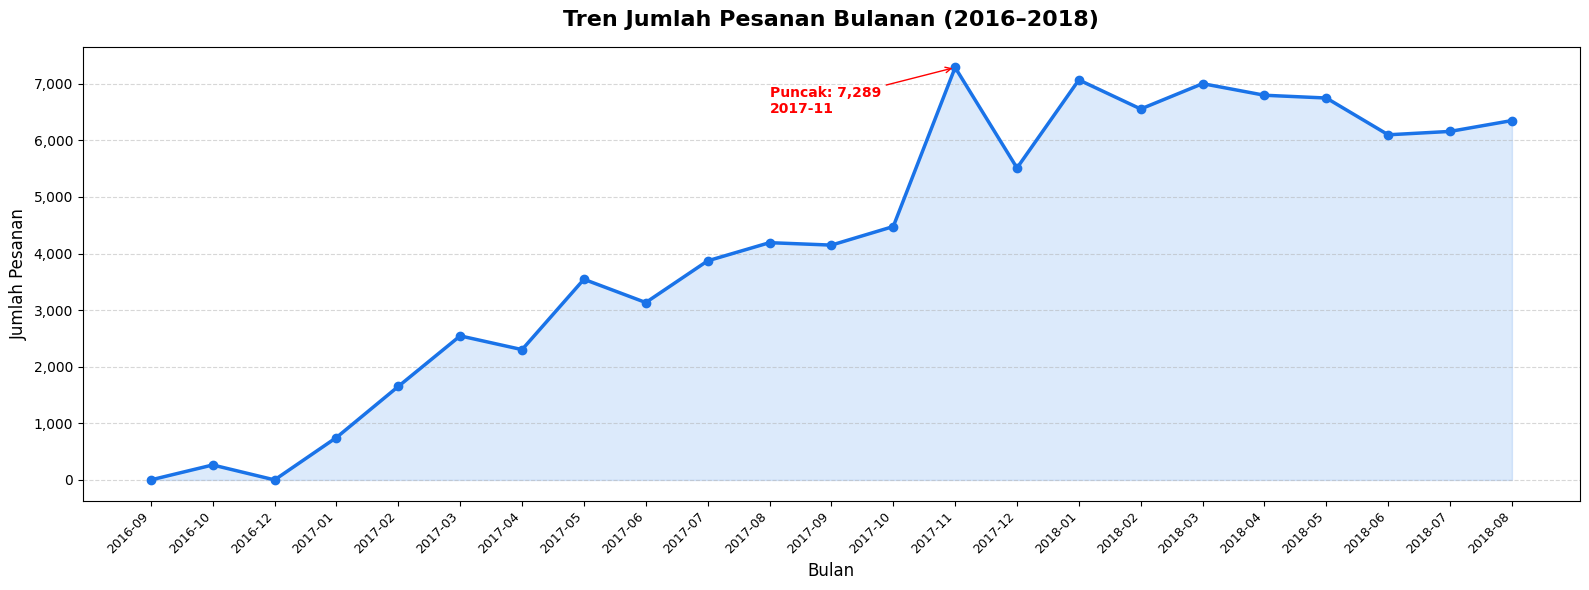

In [22]:
fig, ax = plt.subplots(figsize=(16, 6))

x = range(len(monthly_orders))
ax.plot(x, monthly_orders['total_orders'], marker='o', color='#1a73e8', linewidth=2.5, markersize=6)
ax.fill_between(x, monthly_orders['total_orders'], alpha=0.15, color='#1a73e8')

# Annotate peak
peak_idx = monthly_orders['total_orders'].idxmax()
ax.annotate(
    f"Puncak: {monthly_orders.loc[peak_idx, 'total_orders']:,}\n{monthly_orders.loc[peak_idx, 'year_month_str']}",
    xy=(peak_idx, monthly_orders.loc[peak_idx, 'total_orders']),
    xytext=(peak_idx - 3, monthly_orders.loc[peak_idx, 'total_orders'] - 800),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=10, color='red', fontweight='bold'
)

ax.set_xticks(x)
ax.set_xticklabels(monthly_orders['year_month_str'], rotation=45, ha='right', fontsize=9)
ax.set_title('Tren Jumlah Pesanan Bulanan (2016–2018)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Bulan', fontsize=12)
ax.set_ylabel('Jumlah Pesanan', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

> **Insight:** Jumlah pesanan tumbuh konsisten dari 2016 hingga akhir 2017, kemudian mencapai puncaknya. Lonjakan signifikan pada November 2017 kemungkinan berkaitan dengan event **Black Friday / Harbolnas**.

### Pertanyaan 2: Kategori Produk Terlaris & Revenue Tertinggi

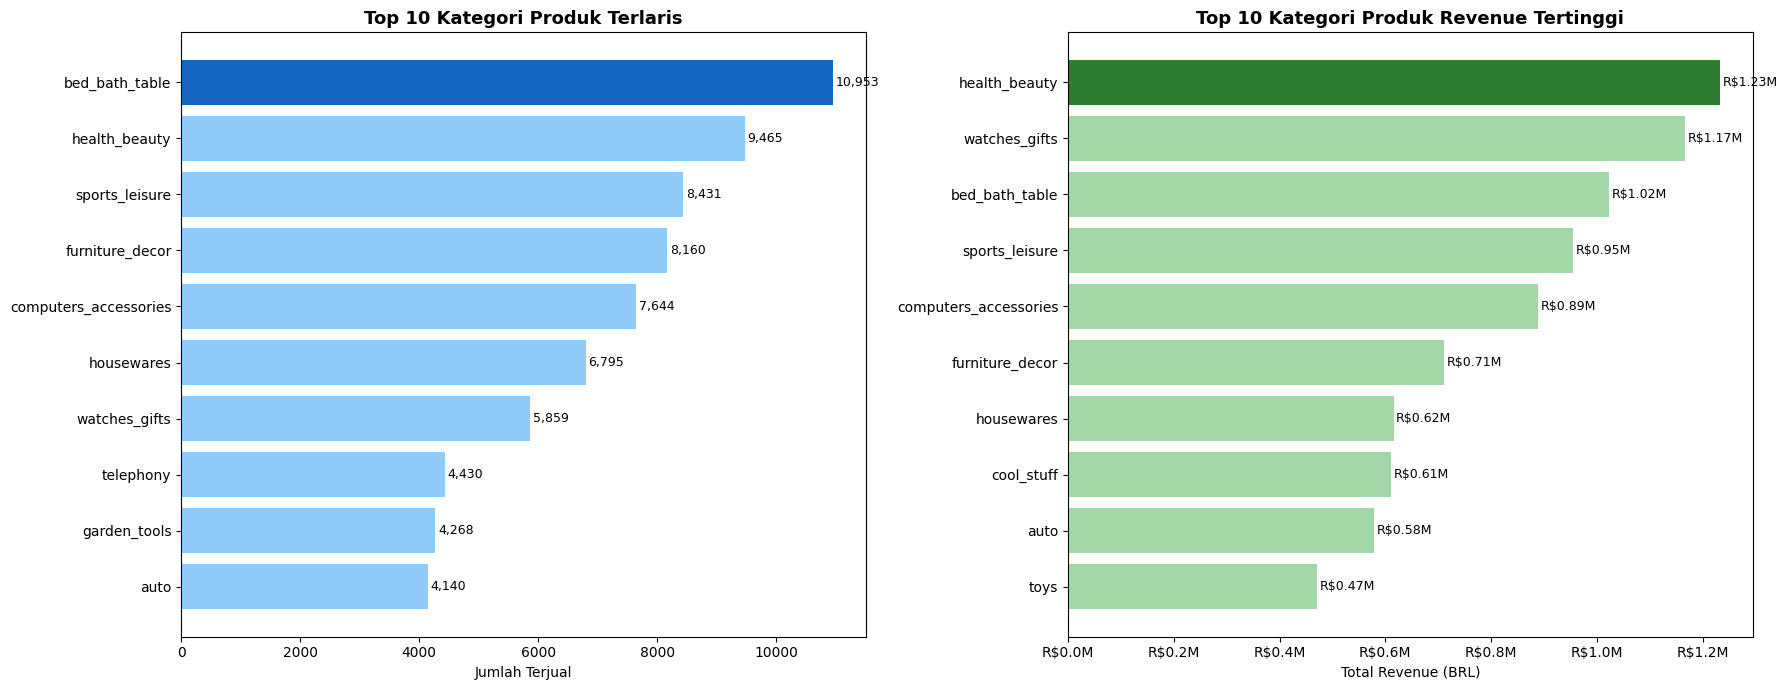

In [32]:
top_n = 10
top_sold = category_sales.head(top_n).sort_values('total_sold')
top_revenue = category_sales.sort_values('total_revenue', ascending=False).head(top_n).sort_values('total_revenue')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors_sold = ['#1565C0' if i == len(top_sold)-1 else '#90CAF9' for i in range(len(top_sold))]
bars1 = axes[0].barh(top_sold['product_category_name_english'], top_sold['total_sold'], color=colors_sold)
axes[0].set_title(f'Top {top_n} Kategori Produk Terlaris', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Terjual')
for bar in bars1:
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, f'{int(bar.get_width()):,}', va='center', fontsize=9)

colors_rev = ['#2E7D32' if i == len(top_revenue)-1 else '#A5D6A7' for i in range(len(top_revenue))]
bars2 = axes[1].barh(top_revenue['product_category_name_english'], top_revenue['total_revenue'], color=colors_rev)
axes[1].set_title(f'Top {top_n} Kategori Produk Revenue Tertinggi', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Revenue (BRL)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
for bar in bars2:
    axes[1].text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2, f'R${bar.get_width()/1e6:.2f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

> **Insight:** `bed_bath_table` dan `health_beauty` mendominasi sisi jumlah terjual. Dari sisi revenue, `health_beauty` dan `watches_gifts` menghasilkan pendapatan tertinggi, mengindikasikan harga produk yang lebih tinggi pada kategori tersebut.

### Pertanyaan 3: Distribusi Geografis Pelanggan per State

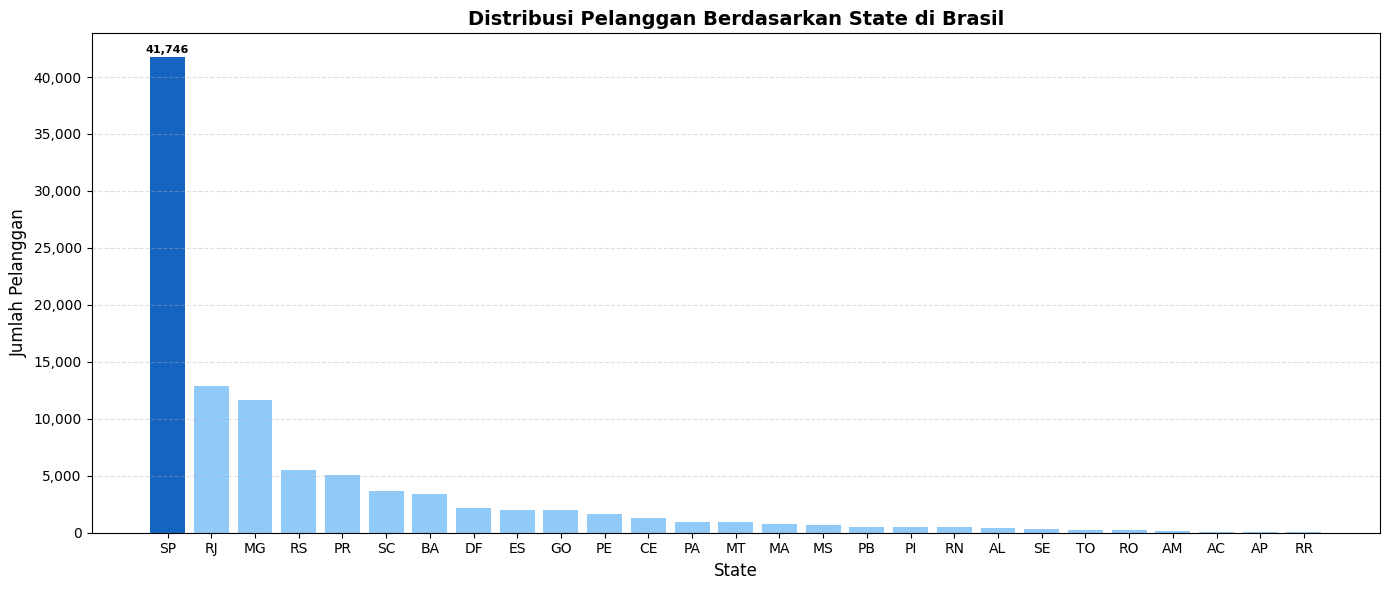

In [35]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#1565C0' if i == 0 else '#90CAF9' for i in range(len(customer_state))]
bars = ax.bar(
    customer_state['customer_state'],
    customer_state['total_customers'],
    color=colors
)

for i, bar in enumerate(bars):
    if i == 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Distribusi Pelanggan Berdasarkan State di Brasil', fontsize=14, fontweight='bold')
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Jumlah Pelanggan', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

> **Insight:** State SP (São Paulo) mendominasi dengan **41.746 pelanggan**, jauh melampaui state lainnya. Diikuti RJ (Rio de Janeiro) dan MG (Minas Gerais). Konsentrasi di wilayah tenggara mencerminkan pusat ekonomi Brasil.

### Pertanyaan 4: Segmentasi Pelanggan (RFM Analysis)

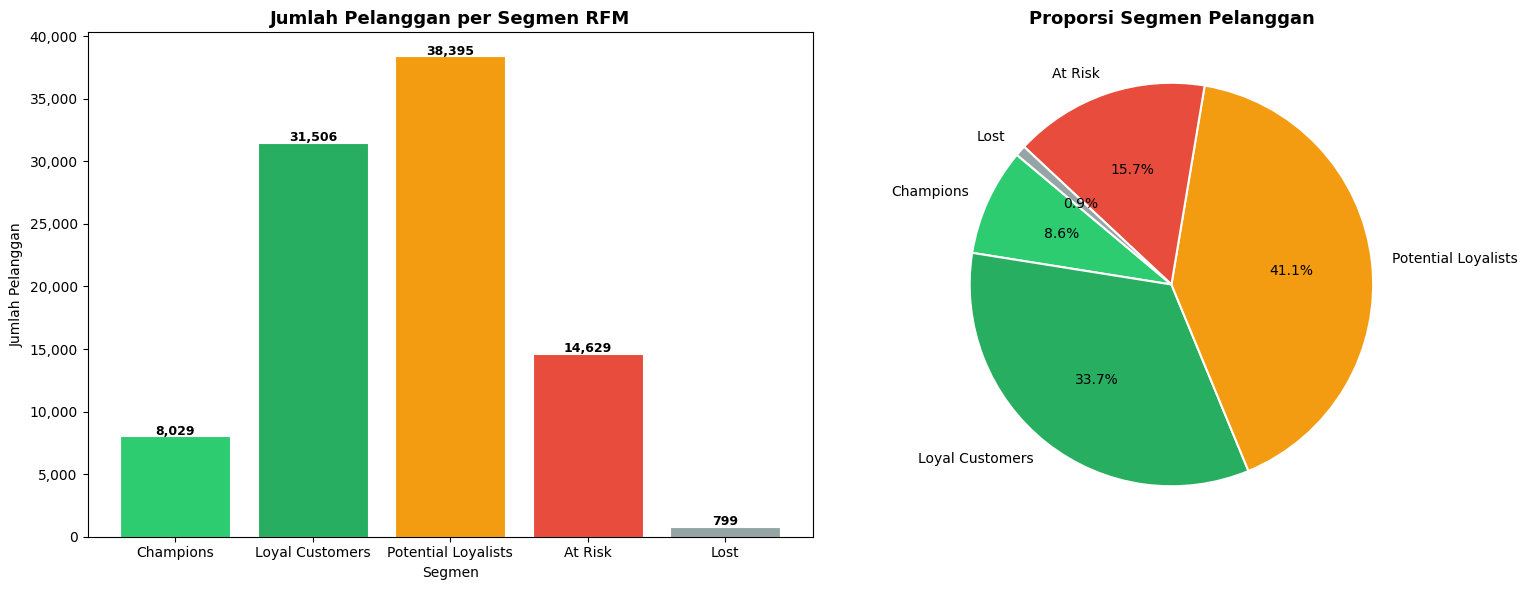

Top 10 Champions (pelanggan terbaik):


,customer_unique_id,Recency,Frequency,Monetary,RFM_Score
2939,07ff81a9676efa0286ddd3f09e7c0063,79,2,484.32,15
725,01f2285f85a1c603eb7ef755ad311769,91,2,463.04,15
3197,08a374bca4063116d5530a7b04ecaf3f,17,2,342.77,15
1173,032b3a42598667caf2e099999b9dc1b9,36,2,495.96,15
1212,0341bbd5c969923a0f801b9e2d10a7b8,92,2,1999.68,15
1249,0361e980b28826f4d286ac144d9b319a,59,2,456.92,15
72518,c6b2ccbe75ac5addb40fcff5db96a5c1,54,2,668.04,15
93113,ff55554082f5ae23537230286bd696c8,85,1,630.44,15
71884,c4de6c1719eff03b6d30aff09571e272,46,2,228.38,15
72485,c694ffd0ff6d172ecf34fcd4202c8693,10,2,332.87,15


In [25]:
segment_counts = rfm_df['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

segment_order = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Lost']
segment_counts['Segment'] = pd.Categorical(segment_counts['Segment'], categories=segment_order, ordered=True)
segment_counts = segment_counts.sort_values('Segment')

colors = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3c', '#95a5a6']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
bars = axes[0].bar(segment_counts['Segment'], segment_counts['Count'], color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Jumlah Pelanggan per Segmen RFM', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Segmen')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=9, fontweight='bold')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    segment_counts['Count'], labels=segment_counts['Segment'],
    autopct='%1.1f%%', colors=colors, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Proporsi Segmen Pelanggan', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Top Champions
print('Top 10 Champions (pelanggan terbaik):')
display(rfm_df[rfm_df['Segment'] == 'Champions'][['customer_unique_id','Recency','Frequency','Monetary','RFM_Score']]
        .sort_values('RFM_Score', ascending=False).head(10))

> **Insight:** Sebagian besar pelanggan berada di segmen **'At Risk'** dan **'Potential Loyalists'**. Rata-rata frekuensi transaksi hanya 1 kali, menandakan rendahnya loyalitas. Diperlukan strategi retensi seperti program loyalitas dan personalized marketing.

## Analisis Lanjutan (Opsional)

### Pertanyaan 5: Sebaran Geospasial Pelanggan & Penjual di Brasil

Analisis ini menjawab: **Di mana konsentrasi pelanggan dan penjual secara geografis di Brasil, dan apakah ada ketimpangan antara lokasi penjual dan pembeli?**

In [26]:
# Gabungkan data pelanggan dengan geolokasi
customers_geo = customers_df.merge(
    geolocation_df[['geolocation_zip_code_prefix','geolocation_lat','geolocation_lng']]
    .drop_duplicates(subset='geolocation_zip_code_prefix'),
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='inner'
)

# Gabungkan data penjual dengan geolokasi
sellers_geo = sellers_df.merge(
    geolocation_df[['geolocation_zip_code_prefix','geolocation_lat','geolocation_lng']]
    .drop_duplicates(subset='geolocation_zip_code_prefix'),
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='inner'
)

print(f'Pelanggan dengan koordinat : {customers_geo.shape[0]:,}')
print(f'Penjual  dengan koordinat  : {sellers_geo.shape[0]:,}')

Pelanggan dengan koordinat : 99,163
Penjual  dengan koordinat  : 3,088


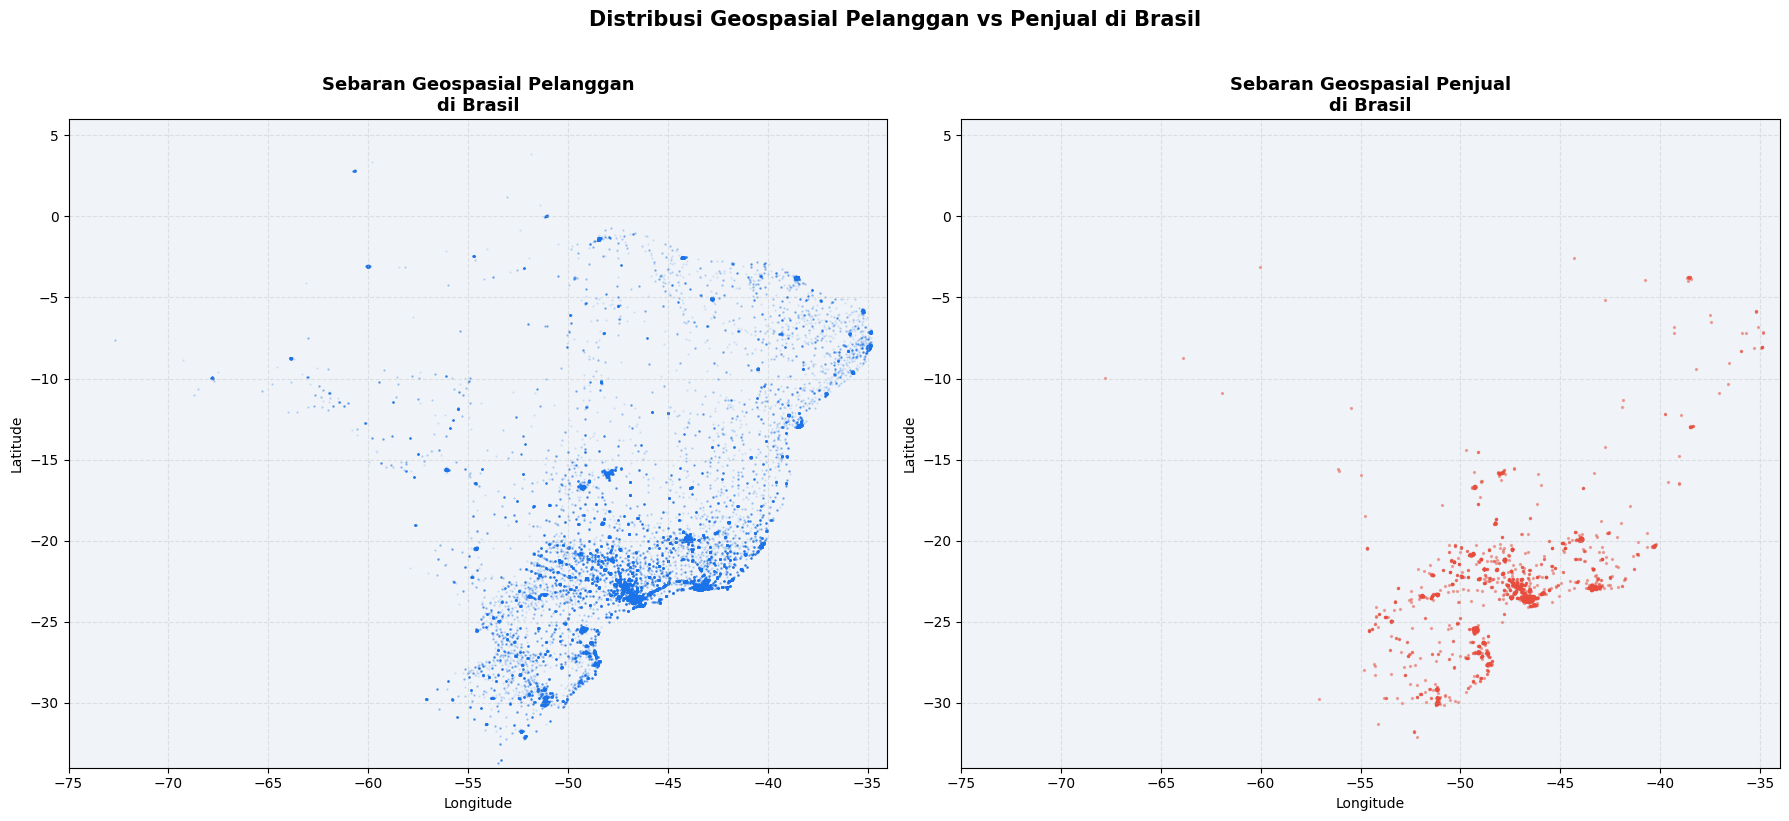

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot Pelanggan
axes[0].scatter(
    customers_geo['geolocation_lng'],
    customers_geo['geolocation_lat'],
    s=0.3, alpha=0.15, color='#1a73e8', rasterized=True
)
axes[0].set_title('Sebaran Geospasial Pelanggan\ndi Brasil', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_xlim(-75, -34)
axes[0].set_ylim(-34, 6)
axes[0].set_facecolor('#f0f4f8')
axes[0].grid(True, linestyle='--', alpha=0.3)

# Plot Penjual
axes[1].scatter(
    sellers_geo['geolocation_lng'],
    sellers_geo['geolocation_lat'],
    s=2, alpha=0.4, color='#e74c3c', rasterized=True
)
axes[1].set_title('Sebaran Geospasial Penjual\ndi Brasil', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_xlim(-75, -34)
axes[1].set_ylim(-34, 6)
axes[1].set_facecolor('#f0f4f8')
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Distribusi Geospasial Pelanggan vs Penjual di Brasil',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# Heatmap density per state: pelanggan vs penjual 
cust_by_state   = customers_df['customer_state'].value_counts().rename('customers')
seller_by_state = sellers_df['seller_state'].value_counts().rename('sellers')

state_comparison = pd.concat([cust_by_state, seller_by_state], axis=1).fillna(0).astype(int)
state_comparison['ratio_cust_per_seller'] = (
    state_comparison['customers'] / state_comparison['sellers'].replace(0, np.nan)
).round(1)
state_comparison = state_comparison.sort_values('customers', ascending=False)

print('Perbandingan Pelanggan vs Penjual per State (Top 15):')
display(state_comparison.head(15))

Perbandingan Pelanggan vs Penjual per State (Top 15):


,customers,sellers,ratio_cust_per_seller
SP,41746,1849,22.6
RJ,12852,171,75.2
MG,11635,244,47.7
RS,5466,129,42.4
PR,5045,349,14.5
SC,3637,190,19.1
BA,3380,19,177.9
DF,2140,30,71.3
ES,2033,23,88.4
GO,2020,40,50.5


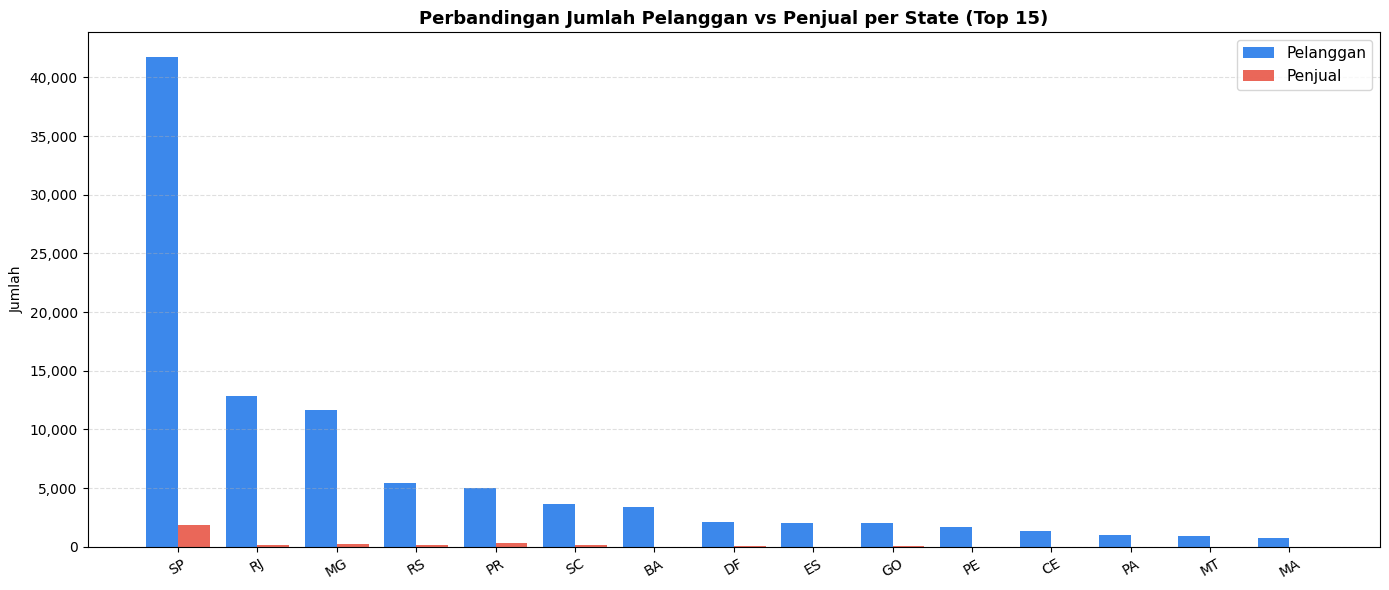

In [29]:
# Bar chart perbandingan 
top15 = state_comparison.head(15)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(top15))
width = 0.4

b1 = ax.bar(x - width/2, top15['customers'], width, label='Pelanggan', color='#1a73e8', alpha=0.85)
b2 = ax.bar(x + width/2, top15['sellers'],   width, label='Penjual',   color='#e74c3c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(top15.index, rotation=30)
ax.set_title('Perbandingan Jumlah Pelanggan vs Penjual per State (Top 15)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

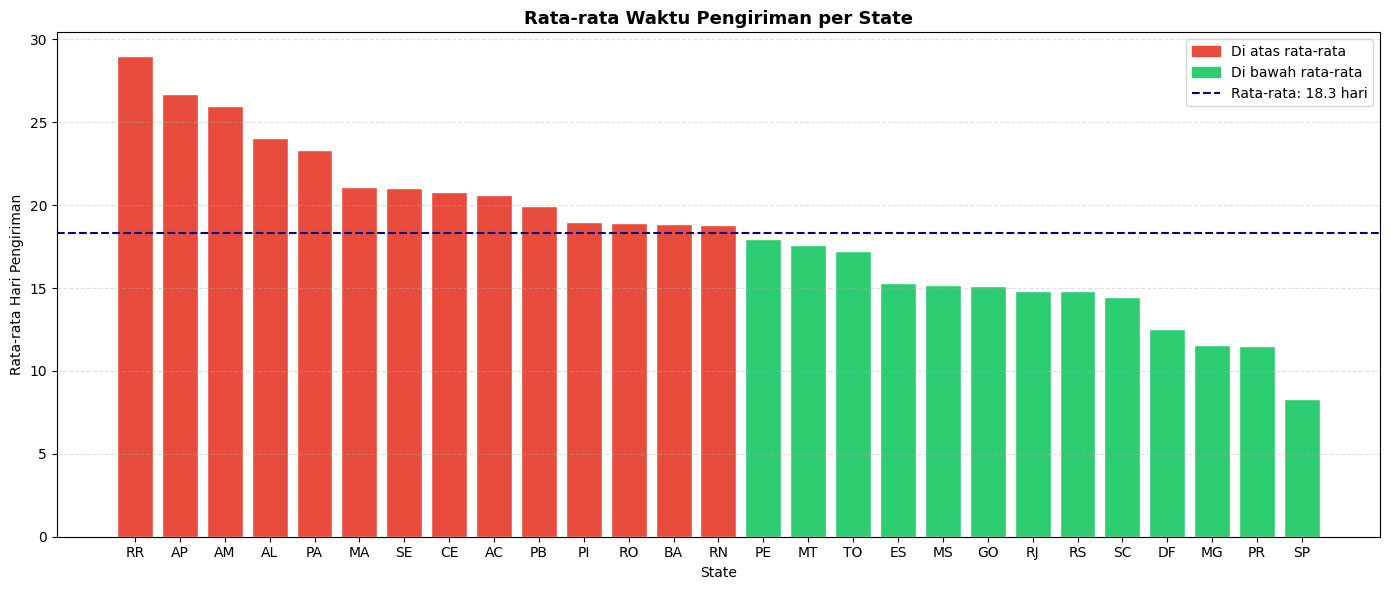

In [30]:
# Analisis rata-rata waktu pengiriman per state 
orders_with_delivery = orders_delivered.dropna(subset=['order_delivered_customer_date']).copy()
orders_with_delivery['delivery_days'] = (
    orders_with_delivery['order_delivered_customer_date'] -
    orders_with_delivery['order_purchase_timestamp']
).dt.days

delivery_by_state = orders_with_delivery.merge(
    customers_df[['customer_id', 'customer_state']], on='customer_id', how='left'
)

avg_delivery = delivery_by_state.groupby('customer_state')['delivery_days'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors_d = ['#e74c3c' if v > avg_delivery.mean() else '#2ecc71' for v in avg_delivery.values]
ax.bar(avg_delivery.index, avg_delivery.values, color=colors_d, edgecolor='white')
ax.axhline(avg_delivery.mean(), color='navy', linestyle='--', linewidth=1.5,
           label=f'Rata-rata: {avg_delivery.mean():.1f} hari')
ax.set_title('Rata-rata Waktu Pengiriman per State', fontsize=13, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Rata-rata Hari Pengiriman')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
patch_slow = mpatches.Patch(color='#e74c3c', label='Di atas rata-rata')
patch_fast = mpatches.Patch(color='#2ecc71', label='Di bawah rata-rata')
ax.legend(handles=[patch_slow, patch_fast,
          plt.Line2D([0],[0], color='navy', linestyle='--', label=f'Rata-rata: {avg_delivery.mean():.1f} hari')],
          fontsize=10)
plt.tight_layout()
plt.show()

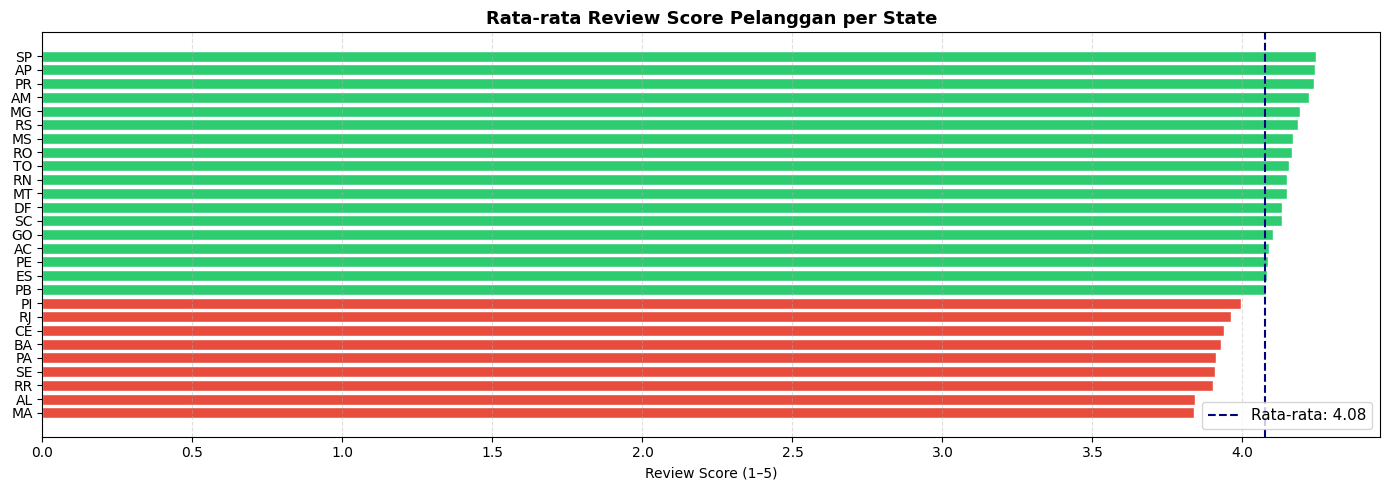

In [31]:
# Review score rata-rata per state
reviews_orders = order_reviews_df.merge(
    orders_delivered[['order_id', 'customer_id']], on='order_id', how='inner'
)
reviews_state = reviews_orders.merge(
    customers_df[['customer_id', 'customer_state']], on='customer_id', how='left'
)

avg_score_state = reviews_state.groupby('customer_state')['review_score'].mean().sort_values()

fig, ax = plt.subplots(figsize=(14, 5))
colors_s = ['#e74c3c' if v < avg_score_state.mean() else '#2ecc71' for v in avg_score_state.values]
ax.barh(avg_score_state.index, avg_score_state.values, color=colors_s, edgecolor='white')
ax.axvline(avg_score_state.mean(), color='navy', linestyle='--', linewidth=1.5,
           label=f'Rata-rata: {avg_score_state.mean():.2f}')
ax.set_title('Rata-rata Review Score Pelanggan per State', fontsize=13, fontweight='bold')
ax.set_xlabel('Review Score (1–5)')
ax.legend(fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

> **Insight Analisis Lanjutan:**
> - Secara geospasial, **pelanggan dan penjual sama-sama terkonsentrasi di wilayah tenggara Brasil** (SP, RJ, MG), membentuk kluster padat yang mencerminkan pusat ekonomi negara.
> - State SP memiliki rasio pelanggan/penjual paling tinggi, artinya **permintaan jauh melebihi kapasitas penjual lokal** — peluang bagi penjual baru untuk masuk.
> - State-state di wilayah utara dan timur laut (AM, RR, AP) memiliki **waktu pengiriman paling lama**, yang berkorelasi dengan **review score lebih rendah**.
> - Strategi **ekspansi gudang/logistik ke wilayah utara** dapat meningkatkan kepuasan pelanggan dan membuka pasar baru.

# Conclusion Analisis E-Commerce


## 1. Tren Pesanan Bulanan

Pesanan mengalami pertumbuhan signifikan dari 2016 hingga pertengahan 2018, dengan puncak tertinggi terjadi di **November 2017** — kemungkinan besar dipicu oleh event Black Friday/Cyber Monday. Setelah puncak tersebut, tren cenderung stabil sebelum sedikit menurun di akhir periode data.


## 2. Kategori Produk Terlaris & Revenue Tertinggi

Kategori **bed_bath_table**, **health_beauty**, dan **sports_leisure** mendominasi dari sisi volume penjualan, sementara kategori seperti **computers** dan **furniture** menghasilkan revenue tinggi meski volumenya lebih rendah karena harga satuan yang mahal.

Terdapat dua segmen pasar yang berbeda. Pertama, segmen *high-volume low-margin* dengan banyak transaksi namun margin tipis, contohnya bed_bath_table dan health_beauty. Kedua, segmen *low-volume high-margin* dengan sedikit transaksi namun nilai jual tinggi per unit, contohnya computers dan furniture.


## 3. Distribusi Pelanggan per State

Pelanggan sangat terkonsentrasi di tiga state utama, yaitu **São Paulo (SP)**, **Rio de Janeiro (RJ)**, dan **Minas Gerais (MG)**. State-state di utara dan timur laut memiliki penetrasi yang sangat rendah.


## 4. Analisis Geospasial Pelanggan vs Penjual

Sebaran penjual jauh lebih terkonsentrasi dibanding pelanggan mayoritas penjual berada di SP. Rasio pelanggan per penjual di beberapa state sangat tinggi, menandakan adanya **permintaan yang tidak terlayani secara lokal**, yang berdampak langsung pada lamanya waktu pengiriman ke wilayah-wilayah tersebut.


## 5. Waktu Pengiriman & Review Score

State-state di wilayah utara dan timur laut Brasil seperti RR, AP, dan AM mencatat rata-rata waktu pengiriman paling lama sekaligus review score yang lebih rendah. Keduanya saling berkorelasi, mengkonfirmasi bahwa **kecepatan pengiriman adalah faktor kunci kepuasan pelanggan**.


## 6. Segmentasi RFM

Mayoritas pelanggan masuk ke segmen **At Risk** atau **Lost**, mengindikasikan tingkat retensi yang rendah, kemungkinan besar karena banyak pelanggan hanya melakukan pembelian sekali (*one-time buyers*). Segmen **Champions** dan **Loyal Customers** hanya mencakup sebagian kecil dari total basis pelanggan.
